# Analysis of confirmation Bias in CoT

## *Dependency*

In [1]:
import os
import re
import copy
import time
import pickle
import torch
import pandas as pd
import numpy as np
from scipy.stats import entropy
from scipy.special import softmax
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from nltk import word_tokenize, sent_tokenize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import mode
from tqdm.notebook import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from biasedcot.utils.plot import jointplot
from biasedcot.utils.evaluate import (
    get_difficulty,
    get_choices,
    get_rationale_coherent_matrix,
    get_rationale_explicit_matrics,
    get_logsumexp,
    parse_llm_label
)
AL = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']

# Load entailment model
entail_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-large-mnli").to('cuda:0')
entail_tokenizer = AutoTokenizer.from_pretrained("roberta-large-mnli")

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


## *Preprocessing*

#### Arguments:

In [2]:
model_option = 'mistral-7B'
dataset_name = 'commonsense_qa'
splits = 'validation'
sampling = True
llm_options = ['claude-3.5-sonnet', 'llama-3.3-70b-instruct', 'deepseek-chat', 'gpt-4o-mini']  # LLMs that have run to extract A_inter

#### Main Calls:

In [3]:
# Load the generative results based on the arguments
result_path = f'../results/{model_option}_{dataset_name}_{splits}'
if sampling:
    result_path += '_sampling'
result_path += '.pk'
with open(result_path, 'rb') as f:
    cot_result_list = pickle.load(f)

# Load the pseudo_label A_inter generated by `llms.py` given `llm_options`. 
if sampling:  # our analytic experiments are only performed on sampled outputs instead of greedy decoded.
    global_llm_labels = []
    for llm_option in llm_options:
        llms_path = f'../results/{llm_option.split("/")[-1]}_{model_option}_{dataset_name}'
        if sampling:
            llms_path += '_sampling'
        llms_path += '.pk'
        with open(llms_path, 'rb') as f:
            llm_result_list = pickle.load(f)
        llm_labels = parse_llm_label(llm_result_list, cot_result_list)
        global_llm_labels.append(llm_labels)
    global_llm_labels = np.array(global_llm_labels)
    pseudo_label_list = list(mode(global_llm_labels, axis=0, keepdims=False).mode)  # majority voting from llms

[WARNING] Ignore invalid content of ['none of the above, as the rationale clearly explains that none o']
[WARNING] Ignore invalid content of ['cannot be determined']
[WARNING] Ignore invalid content of ['none of the above']
[WARNING] Ignore invalid content of ['none of the above - the answer choices provided do not include a']
[WARNING] Ignore invalid content of ['none of the above since none of the given options represent a la']
[WARNING] Ignore invalid content of ['none of the above can be determined with certainty based on the ']
[WARNING] Ignore invalid content of ['none of the above, as injecting water into yourself is unsafe an']
[WARNING] Ignore invalid content of ['none of the above']
[WARNING] Ignore invalid content of ['none of the above']
[WARNING] Ignore invalid content of ['none of the above choices are correct']
[WARNING] Ignore invalid content of ['"none of the above" (as none of the given options are appropriat']
[WARNING] Ignore invalid content of ['none of the above']

In [4]:
# Compute beliefs, CoT attribute and CoT performance
force_recompute = False                # whether to recompute or use cached results
save_file = True                       # cache the all computed results into `../results/attribute_{model_option}_{dataset_name}_{splits}`
compute_rationale_attributes = True    # whether to compute rationale attributes that rely on entailment
use_pseudo_idx = True                  # whether to use llms' results as A_{inter}

feature_path = f'../results/attribute_{model_option}_{dataset_name}_{splits}'
if sampling:
    feature_path += '_sampling'
feature_path += '.pk'

if force_recompute or not os.path.exists(feature_path):
    features = defaultdict(list)
    for idx in tqdm(range(len(cot_result_list))):
        o = cot_result_list[idx]
        targets = copy.deepcopy(o['targets'])
        choices = get_choices(targets, include_letter=False)
        base_probs = softmax(o['base_scores'])
                
        # prepare cot attributes (configurate greedy decoding and sampling)
        cot_f, cot_f_idx, cot_f_scores = o['cot_f'], o['cot_f_idx'], o['cot_f_scores']
        if not sampling:
            cot_f, cot_f_idx, cot_f_scores = [cot_f], [cot_f_idx], [cot_f_scores]

        cot_f_suff_scores = None
        if 'cot_f_suff_scores' in o:
            cot_f_suff_scores = o['cot_f_suff_scores']
            if not sampling:
                cot_f_suff_scores = [cot_f_suff_scores]

        # iterate through all the cot candidates
        for s_i in range(len(cot_f)):
            cot_probs = softmax(cot_f_scores[s_i])

            # question attributes
            features['labels'].append(o['gt_idx'])
            features['base_predicts'].append(o['base_idx'])
            features['base_entropy'].append(entropy(base_probs) / np.log(len(base_probs)))  # normalized
            features['base_difficulty'].append(get_difficulty(o['base_scores'], o['gt_idx']))
            features['base_margin'].append(sorted(base_probs)[-1] - sorted(base_probs)[-2])
            features['base_performance'].append(o['base_idx'] == o['gt_idx'])
        
            # question-answer attributes
            if not use_pseudo_idx:
                label_idx = cot_f_idx[s_i]
            elif sampling:
                assert len(pseudo_label_list[idx]) == len(cot_f)
                label_idx = pseudo_label_list[idx][s_i]
                features['pseudo_labels'].append(label_idx)
            else:  # sampling=False
                label_idx = o['pseudo_idx']
                features['pseudo_labels'].append(label_idx)
                
            # cot attributes (fast)
            features['cot_predicts'].append(cot_f_idx[s_i])
            features['cot_entropy'].append(entropy(cot_probs) / np.log(len(cot_probs)))
            features['cot_performance'].append(cot_f_idx[s_i] == o['gt_idx'])
            features['cot_performance(inter)'].append(cot_f_idx[s_i] == label_idx)  # only valid if use_pseudo_idx=True
            features['cot_consistency(e2e)'].append(o['base_idx'] == cot_f_idx[s_i])
            features['cot_consistency(inter)'].append(o['base_idx'] == label_idx)  # only valid if use_pseudo_idx=True
            features['cot_pmi'].append(np.log(cot_probs[o['gt_idx']] / base_probs[o['gt_idx']]))
            if label_idx == len(cot_probs):  # when use_pseudo_idx=True & pseudo_label='none of above' 
                features['cot_pmi(inter)'].append(-1)
            else:
                features['cot_pmi(inter)'].append(np.log(cot_probs[label_idx] / base_probs[label_idx]))
            features['cot_length'].append(len(word_tokenize(cot_f[s_i])))
            
            # cot attributes computed by entailment
            if compute_rationale_attributes:
                r_probs = softmax(cot_f_suff_scores[s_i])
                cot_f_suff_idx = np.argmax(cot_f_suff_scores[s_i])
                features['cot_pmi(suff)'].append(np.log(cot_probs[cot_f_idx[s_i]] / r_probs[cot_f_idx[s_i]]))
                features['cot_sufficiency'].append(cot_f_suff_idx != cot_f_idx[s_i])
                
                mw_inds = [j for j in range(len(choices)) if j != label_idx]
                cot_coherent_matrix = get_rationale_coherent_matrix(entail_model, entail_tokenizer, cot_f[s_i], choices)
                cot_explicit_matrix_pos, cot_explicit_matrix_neg = \
                    get_rationale_explicit_matrics(entail_model, entail_tokenizer, cot_f[s_i], choices)
                
                cot_mc_inds = np.argwhere(cot_coherent_matrix[:, label_idx] > 0.8).flatten()
                if not len(cot_mc_inds):
                    features['cot_mc_max_pos(step)'].append(-1)
                else:
                    features['cot_mc_max_pos(step)'].append(cot_mc_inds[-1]/cot_coherent_matrix.shape[0])
                features['cot_mc_count(step)'].append(cot_coherent_matrix[:, label_idx].sum())
                features['cot_mc_ratio(step)'].append(cot_coherent_matrix[:, label_idx].mean())
                features['cot_mw_count(step)'].append(cot_coherent_matrix[:, mw_inds].sum(0).mean()) 
                features['cot_mw_ratio(step)'].append(cot_coherent_matrix[:, mw_inds].mean(0).mean()) 
                features['cot_mc_explicit'].append((cot_explicit_matrix_pos[:, label_idx] > 0.9).sum() > 0)
                features['cot_mw_explicit'].append(((cot_explicit_matrix_neg[:, mw_inds] > 0.75).sum(0) > 0).mean())
                features['cot_coherent_matrix'].append(cot_coherent_matrix)
                features['cot_explicit_matrix_pos'].append(cot_explicit_matrix_pos)
                features['cot_explicit_matrix_neg'].append(cot_explicit_matrix_neg)

    if save_file:
        with open(feature_path, 'wb') as f:
            pickle.dump(features, f)
else:
    with open(feature_path, 'rb') as f:
        features = pickle.load(f)

for o in cot_result_list:
    cot_f = o['cot_f']
    if not sampling:
        cot_f = [cot_f]
    for cot_f_i in cot_f:
        features['base_lse'].append(get_logsumexp(o['base_scores']))

raw_features = copy.deepcopy(features)
for key in raw_features:
    if 'matrix' not in key and 'dict' not in key and 'list' not in key:
        features[key] = np.array(features[key])
    else:
        del features[key]
features['cot_sufficiency'] = ~features['cot_sufficiency']

full_tr = pd.DataFrame(features)
full_tr.head()

,labels,base_entropy,base_difficulty,base_margin,base_performance,pseudo_labels,cot_entropy,cot_performance,cot_performance(inter),cot_consistency(e2e),...,cot_pmi(suff),cot_sufficiency,cot_mc_max_pos(step),cot_mc_count(step),cot_mc_ratio(step),cot_mw_count(step),cot_mw_ratio(step),cot_mc_explicit,cot_mw_explicit,base_lse
0,0,0.336518,-2.275704,0.769315,True,0,0.511589,True,True,True,...,0.024798,True,0.400000,1.239038,0.082603,1.656228,0.110415,False,0.50,-0.074987
1,0,0.336518,-2.275704,0.769315,True,0,0.260188,True,True,True,...,0.669674,True,0.888889,1.089035,0.121004,0.149628,0.016625,False,0.00,-0.074987
2,0,0.336518,-2.275704,0.769315,True,0,0.254855,True,True,True,...,0.177595,True,0.857143,1.824352,0.260622,0.486958,0.069565,False,0.25,-0.074987
3,0,0.336518,-2.275704,0.769315,True,0,0.266165,True,True,True,...,-0.054904,True,0.750000,0.927560,0.231890,0.054411,0.013603,True,0.50,-0.074987
4,0,0.336518,-2.275704,0.769315,True,0,0.546658,True,True,True,...,1.551625,False,-1.000000,0.825690,0.103211,0.826633,0.103329,False,0.00,-0.074987


## *Analytic Results*

#### An overview of confirmation bias in $P(A, R|Q, B)$

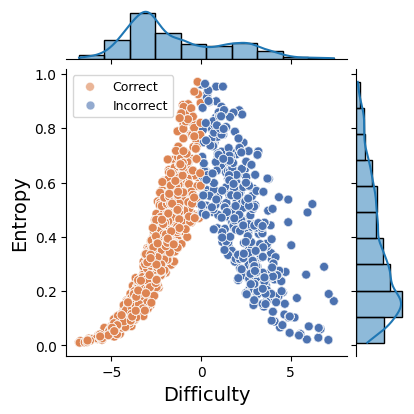

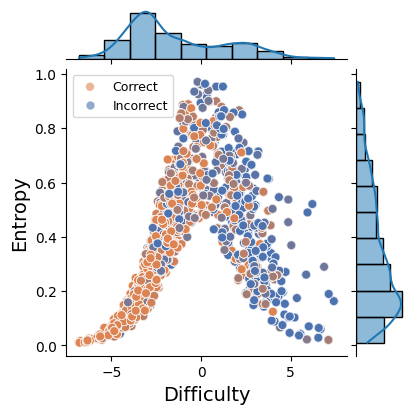

In [5]:
# How CoT change the performance in general
# Figure 1a:
custom_palette = {True: '#DD8452', False: '#4C72B0'}
tr = full_tr
x, y = np.array(full_tr['base_difficulty']), np.array(full_tr['base_entropy'])
select = np.array(full_tr['base_performance'])
g = sns.JointGrid(x=x, y=y, height=4)
sns.scatterplot(x=x, y=y, alpha=0.6, ax=g.ax_joint,
                hue=select, edgecolor='w', s=40, 
                palette=custom_palette)

sns.histplot(data=tr, x=x, ax=g.ax_marg_x, bins=10, kde=True)
sns.histplot(data=tr, y=y, ax=g.ax_marg_y, bins=10, kde=True)

g.set_axis_labels('Difficulty', 'Entropy', fontsize=14)
g.ax_joint.legend(loc='upper left', labels=['Correct', 'Incorrect'], fontsize=9)
plt.savefig(f'../figures/figure2a.png', bbox_inches='tight', dpi=300)

# Figure 1b:
x, y = np.array(full_tr['base_difficulty']), np.array(full_tr['base_entropy'])
select = np.array(full_tr['cot_performance'])
g = sns.JointGrid(x=x, y=y, height=4)
sns.scatterplot(x=x, y=y, alpha=0.6, ax=g.ax_joint,
                hue=select, edgecolor='w', s=40, 
                palette=custom_palette)

sns.histplot(data=tr, x=x, ax=g.ax_marg_x, bins=10, kde=True)
sns.histplot(data=tr, y=y, ax=g.ax_marg_y, bins=10, kde=True)

g.set_axis_labels('Difficulty', 'Entropy', fontsize=14)
g.ax_joint.legend(loc='upper left', labels=['Correct', 'Incorrect'], fontsize=9)
plt.savefig(f'../figures/figure2b.png', bbox_inches='tight', dpi=300)

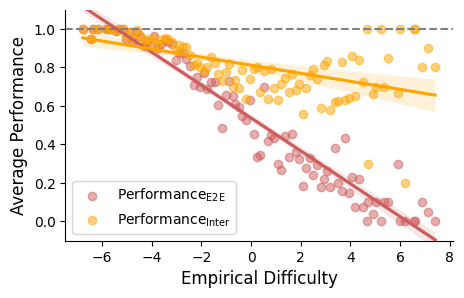

In [6]:
# Stratified analysis on CoT performance with respect to empirical difficulty
selected_tr = full_tr    
k = 100
values = np.array(selected_tr['base_difficulty'])
bins = np.linspace(min(values), max(values), k + 1)
cluster_labels = np.clip(np.digitize(values, bins, right=True), 1, k)
keys = []
for cluster_id in set(cluster_labels):
    keys.append([sum(cluster_labels == cluster_id)] + \
                list(full_tr[cluster_labels == cluster_id].mean(0)))
plot_tr = pd.DataFrame(keys)
plot_tr.columns = ['num_sample'] + list(full_tr.columns)
plot_tr = plot_tr.sort_values(by = 'base_entropy')

# Create a figure with subplots
fig = plt.figure(figsize=(5, 3))
ax_reg = fig.add_subplot()
# sns.set_style()
sns.set_palette("deep")
plt.axhline(y=1, color='grey', linestyle='--')
sns.regplot(plot_tr, x="base_difficulty", y="cot_performance", scatter_kws={"alpha": 0.5}, 
            label=r"Performance$_\text{E2E}$", color='indianred')
sns.regplot(plot_tr, x='base_difficulty', y='cot_performance(inter)', label=r'Performance$_\text{Inter}$', 
            scatter_kws={"alpha": 0.5}, color='#FFA500')

if dataset_name == 'commonsense_qa':
    title = 'CommonsenseQA'
elif dataset_name == 'social_i_qa':
    title = 'SocialIQA'
elif dataset_name == 'piqa':
    title = 'PIQA'
elif dataset_name == 'strategyqa_fact':
    title = 'StrategyQA+F'
elif dataset_name == 'strategyqa':
    title = 'StrategyQA'
else:
    title = 'AQuA'
# plt.title(title, fontsize=14)
plt.ylim(-0.1, 1.1)
plt.legend(fontsize=10)
plt.ylabel('Average Performance', fontsize=12)
plt.xlabel("Empirical Difficulty", fontsize=12)
ax_reg.spines['top'].set_visible(False)
ax_reg.spines['right'].set_visible(False)

plt.savefig('../figures/figure3.png', dpi=300, bbox_inches='tight')
plt.show()

#### Confirmation bias in $P(R|Q,B)$

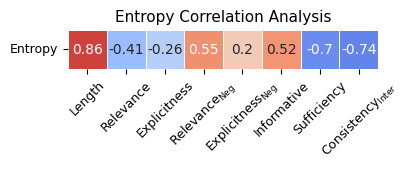

In [7]:
# Stratified correlation analysis between entropy and other factors
selected_tr = full_tr
k = 100
values = np.array(selected_tr['base_entropy'])
bins = np.linspace(min(values), max(values), k + 1)
cluster_labels = np.clip(np.digitize(values, bins, right=True), 1, k)
keys = []
for cluster_id in set(cluster_labels):
    sub_selected_tr = selected_tr[cluster_labels == cluster_id]
    keys.append(list(sub_selected_tr.mean(0)))
        
plot_tr = pd.DataFrame(keys)
plot_tr.columns = list(full_tr.columns)
plot_tr = plot_tr[[
    'base_entropy',
    'cot_length',
    'cot_mc_ratio(step)',
    'cot_mc_explicit',
    'cot_mw_ratio(step)',
    'cot_mw_explicit',
    'cot_pmi(inter)',
    'cot_sufficiency',
    'cot_consistency(inter)',
]]

sns.set_theme()
plt.style.use("default")
correlation_matrix = plot_tr.corr()
plt.figure(figsize=(4, 3))
correlation_matrix = (correlation_matrix[['base_entropy']].T).iloc[:, 1:]
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar=False)
plt.yticks([0.5], ['Entropy'], rotation=360, fontsize=9)
plt.xticks(np.arange(correlation_matrix.shape[1])+0.5, 
           ['Length', 'Relevance', 'Explicitness', 
            r'Relevance$_\text{Neg}$', r'Explicitness$_\text{Neg}$', 
            'Informative', 'Sufficiency', r'Consistency$_\text{Inter}$'],
           rotation=45, fontsize=9)
plt.title("Entropy Correlation Analysis", fontsize=11)
plt.savefig(f'../figures/figure5.png', bbox_inches='tight', dpi=300)
plt.show()

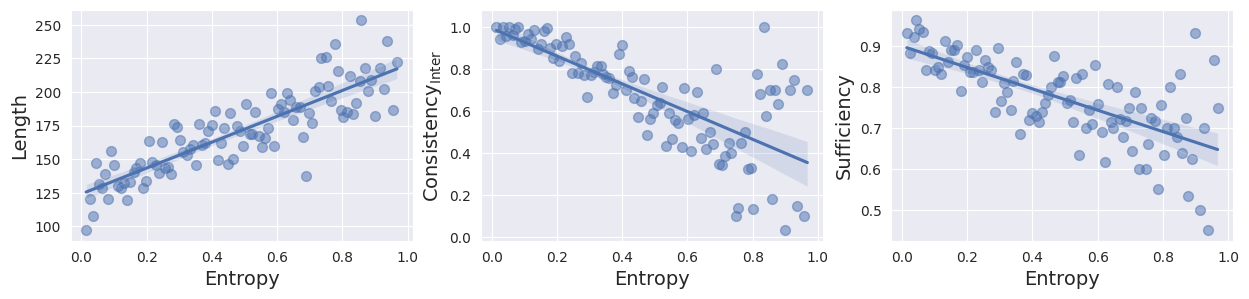

In [8]:
# Example correlation plots
def regplot(data, x, y, ax, params={}):
    sns.set_style("darkgrid")
    sns.set_palette("deep")
    sns.regplot(
        data, x=x, y=y, ax=ax, scatter_kws={"alpha": 0.5, "s": 50}, 
    )
    if 'xlabel' in params:
        ax.set_xlabel(params['xlabel'], fontsize=14)
    if 'ylabel' in params:
        ax.set_ylabel(params['ylabel'], fontsize=14)
    if 'title' in params:
        ax.set_title(params['title'], fontsize=16)

sns.set_style("darkgrid")
sns.set_palette("deep")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 3))
regplot(plot_tr, x='base_entropy', y='cot_length', ax=axes[0], params={
    'xlabel': 'Entropy', 'ylabel': 'Length'
})
regplot(plot_tr, x='base_entropy', y='cot_consistency(inter)', ax=axes[1], params={
    'xlabel': 'Entropy', 'ylabel': r'Consistency$_\text{Inter}$'
})
regplot(plot_tr, x='base_entropy', y='cot_sufficiency', ax=axes[2], params={
    'xlabel': 'Entropy', 'ylabel': r'Sufficiency'
})
plt.savefig(f'../figures/figure4', dpi=300, bbox_inches='tight')
plt.show()

#### Confirmation bias in $P(A|Q,R,B)$

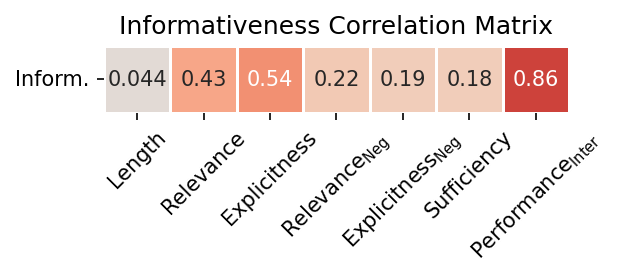

In [9]:
# Stratified correlation analysis between informativeness and other factors
selected_tr = full_tr
sns.set_theme()
plt.style.use("default")

k = 100
values = np.array(selected_tr['cot_pmi(inter)'])
bins = np.linspace(min(values), max(values), k + 1)
cluster_labels = np.clip(np.digitize(values, bins, right=True), 1, k)

keys = []
for cluster_id in set(cluster_labels):
    keys.append([sum(cluster_labels == cluster_id)] + \
                list(selected_tr[cluster_labels == cluster_id].mean(0)))
    
plot_tr = pd.DataFrame(keys)
plot_tr.columns = ['num_sample'] + list(selected_tr.columns)
plot_tr = plot_tr[[
    'cot_pmi(inter)',
    'cot_length',
    'cot_mc_ratio(step)',
    'cot_mc_explicit',
    'cot_mw_ratio(step)',
    'cot_mw_explicit',
    'cot_sufficiency',
    'cot_performance(inter)'
]]

correlation_matrix = plot_tr.corr()
plt.figure(figsize=(4, 4), dpi=150)
sns.heatmap(correlation_matrix[['cot_pmi(inter)']].T.iloc[:, 1:], annot=True, cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar=False)
plt.yticks([0.5], ['Inform.'], rotation=360)
plt.xticks(np.arange(plot_tr.shape[1]-1)+0.5, [
    'Length', 'Relevance', 'Explicitness', 
    r'Relevance$_\text{Neg}$', r'Explicitness$_\text{Neg}$', 'Sufficiency', r'Performance$_\text{Inter}$'
], rotation=45)
plt.title("Informativeness Correlation Matrix")
plt.savefig(f'../figures/figure6a', bbox_inches='tight', dpi=300)
plt.show()

In [10]:
scaler = StandardScaler()
query_name = 'base_entropy'
secondary_query_name = 'cot_pmi(inter)'

# primary grouping
k = 10
values = np.array(selected_tr[query_name])
bins = np.linspace(0, max(values), k + 1)
group_labels = np.clip(np.digitize(values, bins, right=True), 1, k)

primary_distribution_list, secondary_correlation_list, secondary_tr_list, secondary_ytick_list = [], [], [], []
performance_difference_list = []
for cluster_id in set(group_labels):  # iteratively perform secondary grouping
    cluster_features = selected_tr[group_labels == cluster_id]
    cluster_features.reset_index(inplace=True, drop=True)

    k = cluster_features.shape[0] // 2
    values = np.array(cluster_features[secondary_query_name])
    bins = np.linspace(min(values), max(values), k + 1)
    sec_cluster_labels = np.clip(np.digitize(values, bins, right=True), 1, k)

    keys = []
    for sec_cluster_id in set(sec_cluster_labels):
        keys.append([sum(sec_cluster_labels == sec_cluster_id)] + \
                    list(cluster_features[sec_cluster_labels == sec_cluster_id].mean(0)))
    plot_tr = pd.DataFrame(keys)
    plot_tr.columns = ['num_sample'] + list(selected_tr.columns)
    plot_tr = plot_tr[[
        'cot_pmi(inter)',
        'cot_length',
        'cot_mc_ratio(step)',
        'cot_mc_explicit',
        'cot_mw_ratio(step)',
        'cot_mw_explicit',
        'cot_sufficiency',
        'cot_performance(inter)'
    ]]

    correlation_matrix = plot_tr.corr()
    primary_distribution_list.append(cluster_features[query_name])
    secondary_correlation_list.append(correlation_matrix[['cot_pmi(inter)']].T.iloc[:, 1:])
    secondary_tr_list.append(plot_tr)
    secondary_ytick_list.append(f'{round(np.mean(cluster_features[query_name]), 3)} / {cluster_features.shape[0]}')

    performance_diff = np.mean(cluster_features['cot_performance(inter)'])# - np.mean(cluster_features['base_performance'])
    performance_difference_list.append(performance_diff)

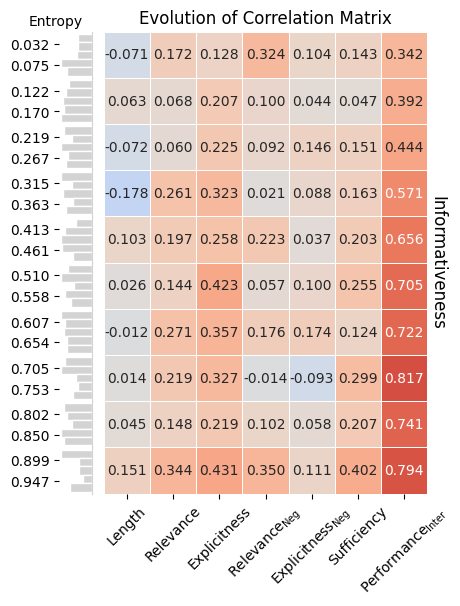

In [11]:
sns.set_theme()
plt.style.use("default")

# Advanced and finalized correlation evolution plots with histogram:
hist_data_list = primary_distribution_list
data = np.array(secondary_correlation_list)[:, 0]
data[np.isnan(data)] = 0
n_rows, n_cols = data.shape

# Create the main figure and heatmap axis
fig, ax_heat = plt.subplots(figsize=(8, 6))
sns.heatmap(data, ax=ax_heat, annot=True, fmt=".3f",
            xticklabels=['Length', 'Relevance', 'Explicitness', 
                          r'Relevance$_\text{Neg}$', r'Explicitness$_\text{Neg}$', 
                         'Sufficiency', r'Performance$_\text{Inter}$'], 
            yticklabels=['']*n_rows, cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5, cbar=False)
ax_heat.tick_params(axis='y', which='both', length=0)
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=45)

ax_heat.set_ylabel("Informativeness", fontsize=12, rotation=-90, labelpad=10)
ax_heat.yaxis.set_label_position("right")
ax_heat.yaxis.tick_right()
ax_heat.set_title('Evolution of Correlation Matrix')

# Get the position of the heatmap axis in figure coordinates
pos = ax_heat.get_position()  # [left, bottom, width, height] in figure coordinates
hist_width = 0.1 * pos.width     
hist_left = pos.x0 - hist_width - 0.015  
hist_x_center = hist_left + hist_width / 2
fig.text(hist_x_center - 0.025, pos.y0 + pos.height + 0.005, "Entropy",
         ha='center', va='bottom')

# Add one histogram per heatmap row.
for i in range(n_rows):
    row_height = 1.0 / n_rows
    bottom = pos.y0 + (n_rows - 1 - i) * row_height * pos.height
    hist_width = 0.1 * pos.width
    gap = 0.015
    hist_left = pos.x0 - hist_width - gap

    ax_hist = fig.add_axes([hist_left, bottom, hist_width, row_height * pos.height])
    _, bins, _ = ax_hist.hist(hist_data_list[i], bins=5, orientation='horizontal', color='lightgrey', edgecolor='w')
    min_bin, max_bin = min(bins), max(bins)
    for key, spine in ax_hist.spines.items():
        if key != 'right':
            spine.set_visible(False)
        else:
            spine.set_color('lightgrey')

    yticks = [round((max_bin-min_bin)*0.25+min_bin, 3),
              round((max_bin-min_bin)*0.75+min_bin, 3)]
    ax_hist.set_yticks(yticks)
    ax_hist.set_xticks([])
    ax_hist.invert_xaxis()
    ax_hist.invert_yaxis()    
    
plt.savefig(f'../figures/figure6b', bbox_inches='tight', dpi=300)
plt.show()

#### Explicitness (positive) strongly correlates with Performance$_\text{inter}$

In [12]:
# Compute average performance for each explicitness groups
categories1 = np.array(full_tr['cot_mc_explicit'])
categories2 = np.array(full_tr['cot_mw_explicit'] > 0)
grouped = defaultdict(list)
for i, (cat1, cat2) in enumerate(zip(categories1, categories2)):
    key = (cat1, cat2) 
    grouped[key].append(i)  

for key in grouped:
    inds = grouped[key]
    acc = np.mean(full_tr['cot_performance(inter)'].iloc[inds])
    print(key, len(inds), acc)

(False, True) 4539 0.7834324741132408
(False, False) 5006 0.8210147822612864
(True, True) 1853 0.9649217485159202
(True, False) 812 0.9630541871921182


#### Confirmation bias across settings

commonsense_qa mistral-7B: 0.7108927108927109, 0.6904176904176904
commonsense_qa llama3-8B: 0.7051597051597052, 0.742014742014742
commonsense_qa olmo2-7B: 0.6232596232596233, 0.7657657657657657
social_i_qa mistral-7B: 0.6509723643807575, 0.6525076765609007
social_i_qa llama3-8B: 0.5644831115660184, 0.6305015353121801
social_i_qa olmo2-7B: 0.5419651995905834, 0.6432958034800409
piqa mistral-7B: 0.8041349292709467, 0.7959738846572362
piqa llama3-8B: 0.720892274211099, 0.7573449401523396
piqa olmo2-7B: 0.6664853101196954, 0.7132752992383025
strategyqa mistral-7B: 0.5938864628820961, 0.6331877729257642
strategyqa llama3-8B: 0.6419213973799127, 0.6681222707423581
strategyqa olmo2-7B: 0.5720524017467249, 0.6069868995633187
strategyqa_fact mistral-7B: 0.7336244541484717, 0.8078602620087336
strategyqa_fact llama3-8B: 0.759825327510917, 0.8165938864628821
strategyqa_fact olmo2-7B: 0.7117903930131004, 0.7379912663755459
aqua mistral-7B: 0.21653543307086615, 0.3425196850393701
aqua llama3-8B: 0.2

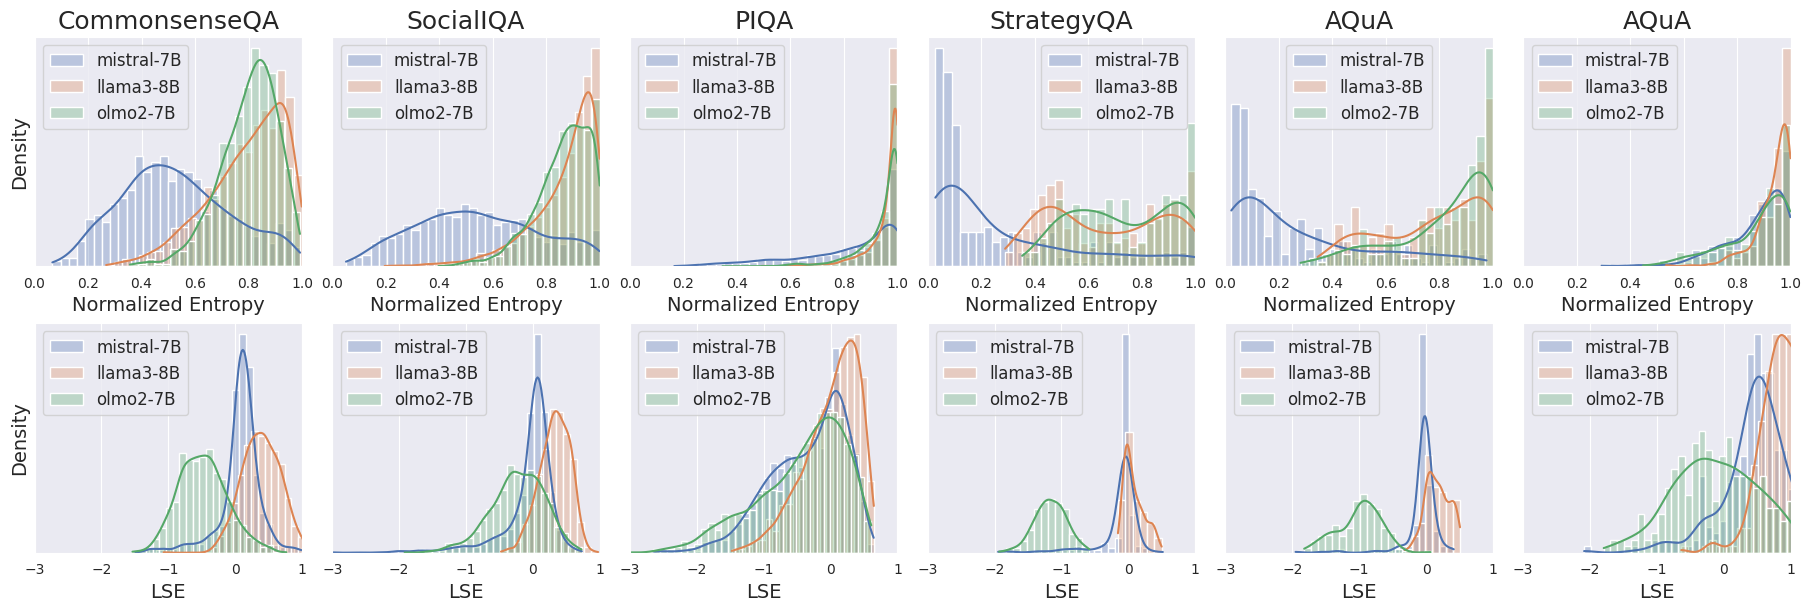

In [13]:
shot = 'zeroshot'
sns.set_style("darkgrid")
sns.set_palette("deep")
dataset2improv = defaultdict(list)
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(18, 6), constrained_layout=True)
for i, dataset_name in enumerate(['commonsense_qa', 'social_i_qa', 'piqa', 'strategyqa', 'strategyqa_fact', 'aqua']):
    for j, model_option in enumerate(['mistral-7B', 'llama3-8B', 'olmo-7B']):
        try:
            with open(f'../results/{model_option}_{dataset_name}_validation.pk', 'rb') as f:
                output_list = pickle.load(f)
        except:
            continue

        if model_option == 'olmo-7B':
            model_option = 'olmo2-7B'
        
        values_a = np.array([entropy(softmax(o['cot_f_scores']))/np.log(len(o['cot_f_scores'])) for o in output_list])
        bin_width = 0.03
        bins = int((max(values_a) - min(values_a)) / bin_width)
        sns.histplot(values_a, bins=bins, kde=True, ax=axes[0][i], stat="density", 
                     alpha=0.3, label=model_option, linewidth=1)

        values_b = np.array([get_logsumexp(o['cot_f_scores']) for o in output_list])
        bin_width = 0.1
        bins = int((max(values_b) - min(values_b)) / bin_width)
        sns.histplot(values_b, bins=bins, kde=True, ax=axes[1][i], stat="density", 
                     alpha=0.3, label=model_option, linewidth=1)

        base_perf = np.array([o['base_idx'] == o['gt_idx'] for o in output_list])
        cot_perf = np.array([o['cot_f_idx'] == o['gt_idx'] for o in output_list])
        print(f'{dataset_name} {model_option}: {np.mean(base_perf)}, {np.mean(cot_perf)}')
        dataset2improv[dataset_name].append(np.mean(cot_perf) - np.mean(base_perf))
                
    axes[0][i].set_xlabel('Normalized Entropy', fontsize=14)
    axes[0][i].set_yticks([])
    axes[0][i].set_yticklabels([])
    axes[0][i].set_xlim(0, 1)

    axes[1][i].set_xlabel('LSE', fontsize=14)
    axes[1][i].set_yticks([])
    axes[1][i].set_yticklabels([])
    axes[1][i].set_xlim(-3, 1)
    if i == 0:
        axes[0][i].set_ylabel('Density', fontsize=14)
        axes[1][i].set_ylabel('Density', fontsize=14)
    else:
        axes[0][i].set_ylabel('')
        axes[1][i].set_ylabel('')
    if dataset_name == 'commonsense_qa':
        title = 'CommonsenseQA'
    elif dataset_name == 'social_i_qa':
        title = 'SocialIQA'
    elif dataset_name == 'piqa':
        title = 'PIQA'
    elif dataset_name == 'strategyqa_fact1':
        title = 'StrategyQA+F'
    elif dataset_name == 'strategyqa':
        title = 'StrategyQA'
    else:
        title = 'AQuA'
    axes[0][i].set_title(title, fontsize=18)
    axes[1][i].legend(fontsize=12)
    legend = axes[0][i].legend(fontsize=12)

plt.savefig(f'../figures/figure7.png', bbox_inches='tight', dpi=300)
plt.show()

#### Informativeness correlates with Performance$_\text{Inter}$

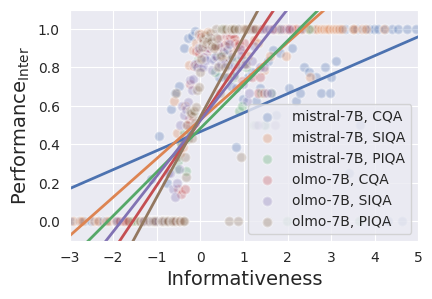

In [15]:
settings = [
    ('mistral-7B', 'commonsense_qa'),
    ('mistral-7B', 'social_i_qa'),
    ('mistral-7B', 'piqa'),
    ('olmo-7B', 'commonsense_qa'),
    ('olmo-7B', 'social_i_qa'),
    ('olmo-7B', 'piqa'),
]

sns.set_style("darkgrid")
sns.set_palette("deep")
fig, ax = plt.subplots(figsize=(4.5, 3))
k = 100
for i, (model_option, dataset_name) in enumerate(settings):    
    # load cot results
    result_path = f'../results/{model_option}_{dataset_name}_validation'
    result_path += '.pk'
    with open(result_path, 'rb') as f:
        cot_result_list = pickle.load(f)

    cot_pmi, cot_performance = [], []
    for o in cot_result_list:
        label_idx = o['pseudo_idx']
        cot_probs = softmax(o['cot_f_scores'])
        base_probs = softmax(o['base_scores'])
        if label_idx > len(cot_probs)-1:
            continue
        cot_pmi.append(np.log(cot_probs[label_idx] / base_probs[label_idx]))
        cot_performance.append(o['cot_f_idx'] == label_idx)
    
    bins = np.linspace(min(cot_pmi), max(cot_pmi), k + 1)
    cluster_labels = np.clip(np.digitize(cot_pmi, bins, right=True), 1, k)
    
    avg_pmi, avg_performance = [], []
    for cluster_id in set(cluster_labels):
        avg_pmi.append(np.mean(np.array(cot_pmi)[cluster_labels == cluster_id]))
        avg_performance.append(np.mean(np.array(cot_performance)[cluster_labels == cluster_id]))

    if dataset_name == 'commonsense_qa':
        dataset_name = 'CQA'
    elif dataset_name == 'social_i_qa':
        dataset_name = 'SIQA'
    else:
        dataset_name = 'PIQA'
        
    sns.scatterplot(x=avg_pmi, y=avg_performance, label=f'{model_option}, {dataset_name}', 
                    alpha=0.3, s=50, linewidth=1.5)
    coeffs = np.polyfit(avg_pmi, avg_performance, deg=1)
    poly_eq = np.poly1d(coeffs)
    tmp_x = np.linspace(-3, 6, 100)
    plt.plot(tmp_x, poly_eq(tmp_x), linewidth=2)
plt.xlim(-3, 5)
plt.ylim(-0.1, 1.1)
plt.xlabel('Informativeness', fontsize=14)
plt.ylabel(r'Performance$_\text{Inter}$', fontsize=14)
plt.savefig('../figures/figures1.png', bbox_inches='tight', dpi=300)